In [151]:
import geopandas as gpd
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

In [152]:
od = 2023

In [153]:
if od == 2023:
    zonas = gpd.read_file(r"Dados\pacote-anexos-od_10-02-25_0\002_Site Metro Mapas\Shape\Zonas_2023.shp")
elif od == 2017:
    zonas = gpd.read_file(r"Dados\OD-2017\Mapas-OD2017\Shape-OD2017\Zonas_2017_region.shp")
zonas

,NumeroZona,NomeZona,NumeroMuni,NomeMunici,NumDistrit,NomeDistri,Area_ha_2,geometry
0,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7..."
1,2,Parque Dom Pedro,36,São Paulo,80,Sé,113.64,"POLYGON ((333106.146 7395425.48, 333120.09 739..."
2,3,Praça João Mendes,36,São Paulo,80,Sé,47.75,"POLYGON ((333353.211 7393933.156, 333238.044 7..."
3,4,Ladeira da Memória,36,São Paulo,67,República,75.11,"POLYGON ((332742.619 7394795.328, 332742.537 7..."
4,5,República,36,São Paulo,67,República,74.95,"POLYGON ((332983.962 7395262.578, 333004.239 7..."
...,...,...,...,...,...,...,...,...
522,523,Quatro Encruzilhadas,17,Itapevi,113,Itapevi,2101.43,"POLYGON ((300336.368 7389696.621, 300324.32 73..."
523,524,Itapevi,17,Itapevi,113,Itapevi,1070.03,"POLYGON ((303326.146 7397176.35, 303326.146 73..."
524,525,Amador Bueno,17,Itapevi,113,Itapevi,5113.23,"POLYGON ((303292.377 7397174.79, 303326.146 73..."
525,526,Santana de Parnaíba,31,Santana de Parnaíba,127,Santana de Parnaíba,18034.76,"POLYGON ((296271.998 7398946.927, 296196.397 7..."


<Axes: >

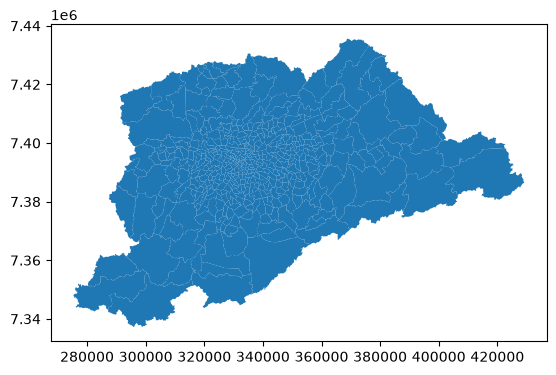

In [154]:
zonas.plot()

In [155]:
linhas = gpd.read_file(r"E:\SPTrans\pedido 096411 - histórico de linhas e mudanças\Linhas - 2023 a 2026.gpkg")
linhas

,ano,trip_id,geometry
0,2023,1012-10-0,"LINESTRING (-46.7871 -23.43217, -46.7871 -23.4..."
1,2023,1012-10-1,"LINESTRING (-46.7995 -23.44466, -46.7995 -23.4..."
2,2023,1012-21-0,"LINESTRING (-46.8019 -23.43907, -46.80201 -23...."
3,2023,1015-10-0,"LINESTRING (-46.78704 -23.43252, -46.78704 -23..."
4,2023,1016-10-0,"LINESTRING (-46.61103 -23.44673, -46.61111 -23..."
...,...,...,...
9199,2026,N839-11-0,"LINESTRING (-46.70929 -23.57174, -46.70934 -23..."
9200,2026,N840-11-0,"LINESTRING (-46.63366 -23.58946, -46.6337 -23...."
9201,2026,N841-11-0,"LINESTRING (-46.63427 -23.58951, -46.63433 -23..."
9202,2026,N842-11-0,"LINESTRING (-46.70146 -23.5662, -46.70144 -23...."


In [156]:
demanda_mes = pd.read_parquet("outputs/Dados_Tarifa_Zero_2023_2025_mes.parquet")
demanda_mes

,linha_blt,zona_emb,Ano,Mês,N_embarques
0,5752-10,279.0,2024,12,32315
1,N501-11,256.0,2024,12,314
2,9784-10,92.0,2024,12,29644
3,N141-11,122.0,2024,12,206
4,351F-10,166.0,2024,12,3098
...,...,...,...,...,...
263892,9012-10,139.0,2023,03,1
263893,N841-11,57.0,2023,03,1
263894,N504-11,41.0,2023,02,2
263895,6960-10,NaN,2024,12,2674


In [157]:
demanda_mes.loc[demanda_mes["Ano"]=="2023"].value_counts("zona_emb")

zona_emb
304.0    1236
2.0      1232
303.0    1182
100.0     941
129.0     934
         ... 
351.0      12
300.0      12
399.0      12
400.0      12
999.0      12
Name: count, Length: 387, dtype: int64

In [158]:
# 2. Join the spatial 'zonas' GeoDataFrame with the demand data
# Using a left join to keep all zones, even those without trips in this specific timeframe
zonas_demanda_2024 = zonas.merge(
    demanda_mes.loc[(demanda_mes["Ano"]=="2024")&(demanda_mes["Mês"]=="04")], 
    left_on="NumeroZona", 
    right_on="zona_emb", 
    how="left",
    #suffixes=["_2024"]
)
print(len(zonas_demanda_2024))

zonas_demanda_2023 = zonas.merge(
    demanda_mes.loc[(demanda_mes["Ano"]=="2023")&(demanda_mes["Mês"]=="04")], 
    left_on=["NumeroZona"], 
    right_on=["zona_emb"], 
    how="left",
)
print(len(zonas_demanda_2023))

11051
10776


In [159]:
zonas_demanda_2023

,NumeroZona,NomeZona,NumeroMuni,NomeMunici,NumDistrit,NomeDistri,Area_ha_2,geometry,linha_blt,zona_emb,Ano,Mês,N_embarques
0,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",3160-10,1.0,2023,04,94.0
1,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",5300-10,1.0,2023,04,1410.0
2,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",5185-10,1.0,2023,04,771.0
3,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",8615-10,1.0,2023,04,498.0
4,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",408A-10,1.0,2023,04,107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10771,523,Quatro Encruzilhadas,17,Itapevi,113,Itapevi,2101.43,"POLYGON ((300336.368 7389696.621, 300324.32 73...",NaN,NaN,NaN,NaN,NaN
10772,524,Itapevi,17,Itapevi,113,Itapevi,1070.03,"POLYGON ((303326.146 7397176.35, 303326.146 73...",NaN,524.0,2023,04,21281.0
10773,525,Amador Bueno,17,Itapevi,113,Itapevi,5113.23,"POLYGON ((303292.377 7397174.79, 303326.146 73...",NaN,NaN,NaN,NaN,NaN
10774,526,Santana de Parnaíba,31,Santana de Parnaíba,127,Santana de Parnaíba,18034.76,"POLYGON ((296271.998 7398946.927, 296196.397 7...",NaN,NaN,NaN,NaN,NaN


In [160]:
zonas_demanda_2024.columns

Index(['NumeroZona', 'NomeZona', 'NumeroMuni', 'NomeMunici', 'NumDistrit',
       'NomeDistri', 'Area_ha_2', 'geometry', 'linha_blt', 'zona_emb', 'Ano',
       'Mês', 'N_embarques'],
      dtype='str')

In [161]:
zonas_demanda = zonas.merge(
    pd.DataFrame(zonas_demanda_2024.groupby(['NumeroZona'])["N_embarques"].sum()).reset_index().replace(0,np.nan),
    left_on="NumeroZona",
    right_on="NumeroZona",
    how="left",
)
zonas_demanda = zonas_demanda.rename(columns={"N_embarques":"N_embarques_2024"})

zonas_demanda = zonas_demanda.merge(
    pd.DataFrame(zonas_demanda_2023.groupby(['NumeroZona'])["N_embarques"].sum()).reset_index().replace(0,np.nan),
    left_on="NumeroZona",
    right_on="NumeroZona",
    how="left",
)
zonas_demanda = zonas_demanda.rename(columns={"N_embarques":"N_embarques_2023"})
zonas_demanda = gpd.GeoDataFrame(zonas_demanda)

zonas_demanda

,NumeroZona,NomeZona,NumeroMuni,NomeMunici,NumDistrit,NomeDistri,Area_ha_2,geometry,N_embarques_2024,N_embarques_2023
0,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",99299.0,68864.0
1,2,Parque Dom Pedro,36,São Paulo,80,Sé,113.64,"POLYGON ((333106.146 7395425.48, 333120.09 739...",493537.0,229813.0
2,3,Praça João Mendes,36,São Paulo,80,Sé,47.75,"POLYGON ((333353.211 7393933.156, 333238.044 7...",104649.0,83400.0
3,4,Ladeira da Memória,36,São Paulo,67,República,75.11,"POLYGON ((332742.619 7394795.328, 332742.537 7...",142380.0,76110.0
4,5,República,36,São Paulo,67,República,74.95,"POLYGON ((332983.962 7395262.578, 333004.239 7...",231917.0,165153.0
...,...,...,...,...,...,...,...,...,...,...
522,523,Quatro Encruzilhadas,17,Itapevi,113,Itapevi,2101.43,"POLYGON ((300336.368 7389696.621, 300324.32 73...",NaN,NaN
523,524,Itapevi,17,Itapevi,113,Itapevi,1070.03,"POLYGON ((303326.146 7397176.35, 303326.146 73...",23720.0,21281.0
524,525,Amador Bueno,17,Itapevi,113,Itapevi,5113.23,"POLYGON ((303292.377 7397174.79, 303326.146 73...",NaN,NaN
525,526,Santana de Parnaíba,31,Santana de Parnaíba,127,Santana de Parnaíba,18034.76,"POLYGON ((296271.998 7398946.927, 296196.397 7...",NaN,NaN


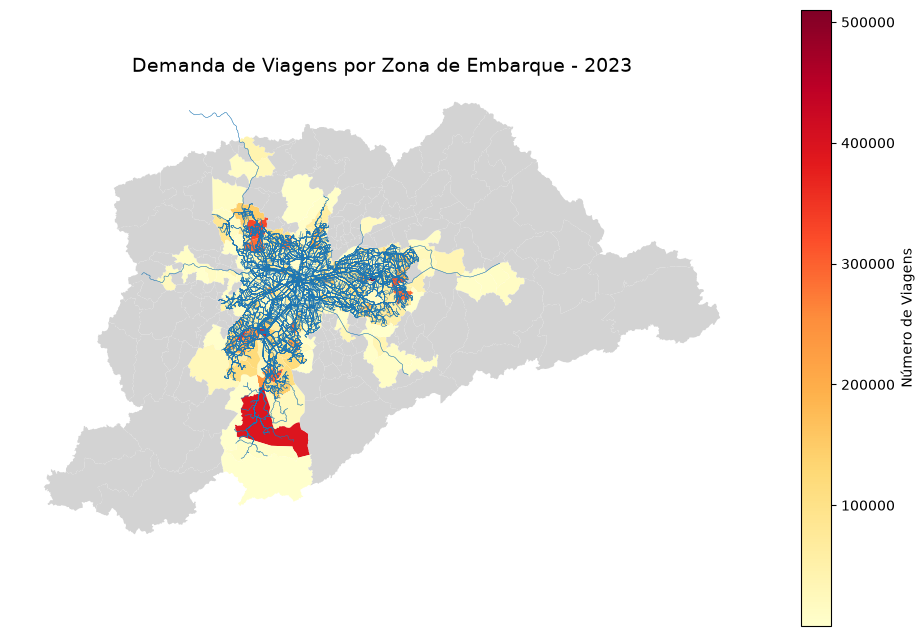

In [162]:
# 3. Plot the result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ano = 2023

zonas_demanda.plot(
    column="N_embarques_{}".format(ano),              # The column we created earlier to count rows
    cmap="YlOrRd",                   # Yellow to Red colormap (great for density/heatmaps)
    legend=True,
    legend_kwds={"label": "Número de Viagens"},
    missing_kwds={"color": "lightgrey"}, # Zones with no matches will be grey
    ax=ax
)

linhas.loc[linhas["ano"]==str(ano)].to_crs("22523").plot(
    linewidth=0.3,
    alpha=0.8,
    ax=ax
    )

# Clean up the map visual
ax.set_title("Demanda de Viagens por Zona de Embarque - {}".format(ano), fontsize=14)
ax.set_axis_off()

plt.show()

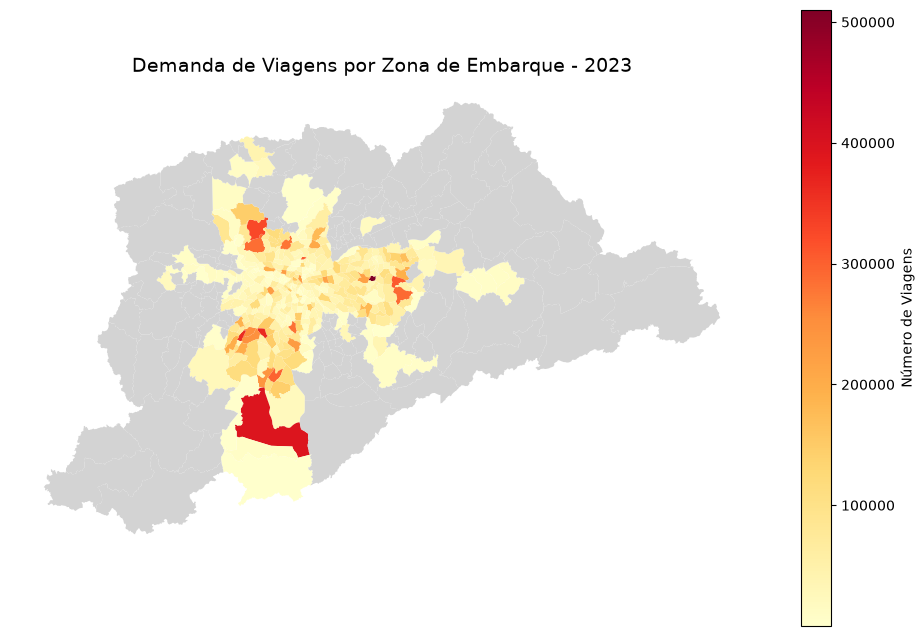

In [163]:
# 3. Plot the result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ano = 2023

zonas_demanda.plot(
    column="N_embarques_{}".format(ano),              # The column we created earlier to count rows
    cmap="YlOrRd",                   # Yellow to Red colormap (great for density/heatmaps)
    legend=True,
    legend_kwds={"label": "Número de Viagens"},
    missing_kwds={"color": "lightgrey"}, # Zones with no matches will be grey
    ax=ax
)

# Clean up the map visual
ax.set_title("Demanda de Viagens por Zona de Embarque - {}".format(ano), fontsize=14)
ax.set_axis_off()

plt.show()

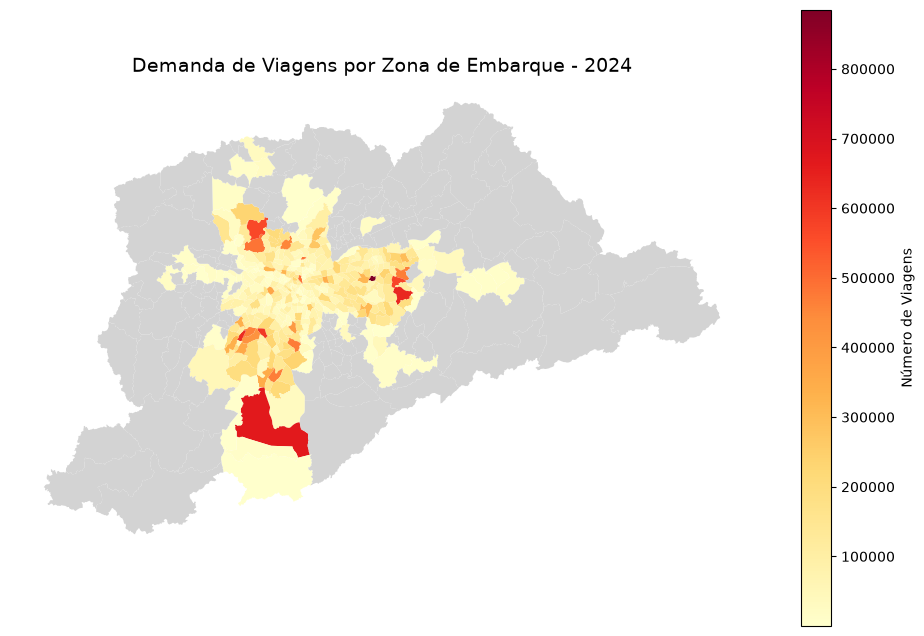

In [164]:
# 3. Plot the result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ano = 2024

zonas_demanda.plot(
    column="N_embarques_{}".format(ano),              # The column we created earlier to count rows
    cmap="YlOrRd",                   # Yellow to Red colormap (great for density/heatmaps)
    legend=True,
    legend_kwds={"label": "Número de Viagens"},
    missing_kwds={"color": "lightgrey"}, # Zones with no matches will be grey
    ax=ax
)

# Clean up the map visual
ax.set_title("Demanda de Viagens por Zona de Embarque - {}".format(ano), fontsize=14)
ax.set_axis_off()

plt.show()

In [165]:
zonas_demanda["Diff_embarques"] = zonas_demanda["N_embarques_2024"] - zonas_demanda["N_embarques_2023"]

In [166]:
import folium
import branca.colormap as cm
import numpy as np

# 1. Convert to WGS84
zonas_demanda_4326 = zonas_demanda.to_crs(epsg=4326)

# 2. Simplify the polygons to reduce points
# A tolerance of 0.0005 degrees is roughly 50 meters, which keeps the visual shape intact 
# but drastically reduces the file size.
zonas_demanda_4326.geometry = zonas_demanda_4326.geometry.simplify(tolerance=0.0005)

# Calcular o centro do mapa automaticamente para o enquadramento inicial
centro_y = zonas_demanda_4326.geometry.centroid.y.mean()
centro_x = zonas_demanda_4326.geometry.centroid.x.mean()

# 2. Definir os limites e tratar assimetrias do zero
vmin = zonas_demanda_4326["Diff_embarques"].min()
vmax = zonas_demanda_4326["Diff_embarques"].max()

if vmin >= 0: vmin = -0.1
if vmax <= 0: vmax = 0.1

# 3. Criar o mapa de cores com o zero fixado no branco (#ffffff)
# O parâmetro 'index' força a distribuição exata das cores nos limites e no centro
colormap = cm.LinearColormap(
    colors=["#d7191c", "#ffffff", "#1a9641"],
    index=[vmin, 0, vmax],
    vmin=vmin,
    vmax=vmax
)
colormap.caption = "Diferença entre Embarques por Zona OD - 2024 x 2023"

# 4. Inicializar o mapa do Folium com um fundo claro (CartoDB Positron)
m = folium.Map(
    location=[centro_y, centro_x], 
    zoom_start=11, 
    tiles="CartoDB positron"
)

# 5. Função de estilização para aplicar as cores e tratar valores nulos (missing_kwds)
def style_function(feature):
    val = feature["properties"]["Diff_embarques"]
    return {
        "fillColor": "lightgrey" if val is None or np.isnan(val) else colormap(val),
        "color": "#333333",  # Cor das bordas das zonas
        "weight": 0.6,       # Espessura das bordas
        "fillOpacity": 0.75  # Opacidade do preenchimento
    }

# 6. Adicionar a camada GeoJSON com Tooltip interativo ao passar o mouse
folium.GeoJson(
    zonas_demanda_4326.__geo_interface__,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=["NumeroZona", "NomeZona", "Diff_embarques"],
        aliases=["Zona OD:", "Nome da Zona:", "Diferença:"],
        localize=True,
        sticky=True
    )
).add_to(m)

# 7. Adicionar a legenda do mapa de cores ao mapa principal
colormap.add_to(m)

# Exibir o mapa no notebook
# Save the map to an external file in your folder
m.save("mapa_diferenca_demanda.html")
m

C:\Users\9837292\AppData\Local\Temp\ipykernel_60536\3786365135.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro_y = zonas_demanda_4326.geometry.centroid.y.mean()
C:\Users\9837292\AppData\Local\Temp\ipykernel_60536\3786365135.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro_x = zonas_demanda_4326.geometry.centroid.x.mean()
